# 01 — EDA
Owner: EDA & Preprocessing lead

Goal: understand class balance, visually inspect positive/negative cases per condition, and check intensity/quality variation across the dataset before any modeling.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

DATA_DIR = '../../data'
labels = pd.read_csv(os.path.join(DATA_DIR, 'train_labels.csv'))
labels.head()

,Image Index,Atelectasis,Effusion,Infiltration,Nodule,Pneumothorax
0,00000013_005.png,0,0,1,0,1
1,00000013_026.png,0,0,0,0,0
2,00000017_001.png,0,0,0,0,0
3,00000042_002.png,0,0,0,0,0
4,00000057_001.png,0,0,0,0,0


## Class balance

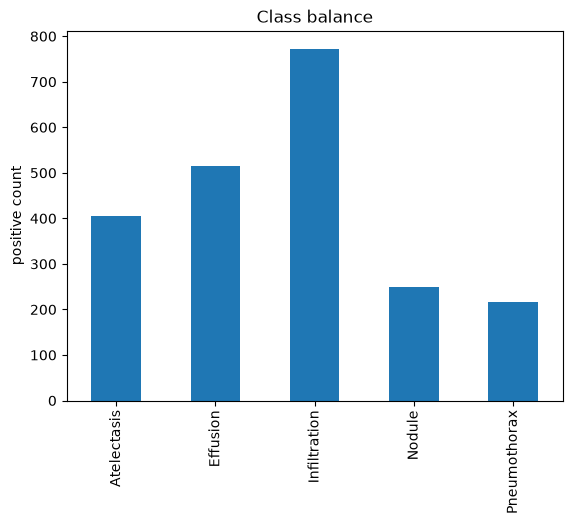

In [5]:
label_cols = ['Atelectasis', 'Effusion', 'Infiltration', 'Nodule', 'Pneumothorax']
labels[label_cols].sum().plot(kind='bar')
plt.ylabel('positive count')
plt.title('Class balance')
plt.show()

## Co-occurrence between conditions
How often do labels overlap on the same image?

In [6]:
labels[label_cols].corr()

,Atelectasis,Effusion,Infiltration,Nodule,Pneumothorax
Atelectasis,1.000000,0.181272,0.069975,-0.012316,0.015760
Effusion,0.181272,1.000000,0.089290,0.031359,0.058919
Infiltration,0.069975,0.089290,1.000000,0.038348,-0.012130
Nodule,-0.012316,0.031359,0.038348,1.000000,0.022200
Pneumothorax,0.015760,0.058919,-0.012130,0.022200,1.000000


## Visual review
Look at a handful of positive vs negative examples per condition — this is required, not optional. Document what you actually notice.

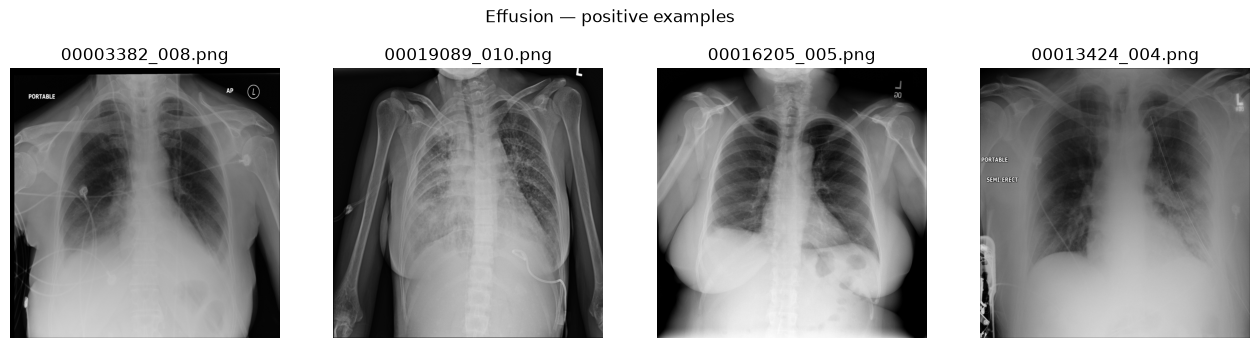

In [ ]:
def show_examples(condition, n=4):
    pos = labels[labels[condition] == 1].sample(n, random_state=1)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    for ax, (_, row) in zip(axes, pos.iterrows()):
        img = cv2.imread(os.path.join(DATA_DIR, 'train', row['Image Index']), cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap='gray')
        ax.set_title(row['Image Index'])
        ax.axis('off')
    plt.suptitle(f'{condition} — positive examples')
    plt.show()

show_examples('Effusion')

## Intensity distribution: positive vs negative
Repeat per condition and note anything worth building a feature around.

In [12]:
 #TODO: compare mean/std pixel intensity distributions for positive vs negative cases per condition